In [1]:
# plotting 
import hist

%matplotlib inline

import mplhep
mplhep.style.use('ROOT')

import matplotlib.pyplot as plt

def title_bar(
    text=None, *,
    by_ldmx='Simulation Internal',
    exp_text_kw = dict(),
    lumitext_kw = dict(),
    **kwargs
):
    """add a title bar to the plot with mplhep

    'LDMX' is the experiment text.

    Parameters
    ----------
    text: str
        given to mplhep.label.lumitext to appear on upper right hand side
        default None
    by_ldmx: str
        written next to the 'LDMX' experiment label in a slightly smaller size
        default 'Internal'
    exp_text_kw: dict
        key-word arguments to pass to mplhep.label.exp_text
    lumitext_kw: dict
        key-word arguments to pass to mplhep.label.lumitext
    kwargs: dict
        additional keywoard arguments passed to both labeling functions
        mostly helpful for uniformly applying style changes
    """
    mplhep.label.exp_text('LDMX', by_ldmx, **exp_text_kw, **kwargs)
    if text is not None:
        mplhep.label.lumitext(text, **lumitext_kw, **kwargs)


def annotate(
    *args,
    loc = None,
    **kwargs
):
    """a simple wrapper around plt.annotate that implements the corner-of-axes shortcuts
    that plt.legend does"""
    if loc == 'upper left':
        kwargs['ha'] = 'left'
        kwargs['va'] = 'top'
        kwargs['xycoords'] = 'axes fraction'
        kwargs['xy'] = (0.05,0.95)
    elif loc == 'upper right':
        kwargs['ha'] = 'right'
        kwargs['va'] = 'top'
        kwargs['xycoords'] = 'axes fraction'
        kwargs['xy'] = (0.95,0.95)
    elif loc == 'lower left':
        kwargs['ha'] = 'left'
        kwargs['va'] = 'bottom'
        kwargs['xycoords'] = 'axes fraction'
        kwargs['xy'] = (0.05,0.05)
    elif loc == 'lower right':
        kwargs['ha'] = 'right'
        kwargs['va'] = 'bottom'
        kwargs['xycoords'] = 'axes fraction'
        kwargs['xy'] = (0.95,0.05)

    return plt.annotate(*args, **kwargs)


In [2]:
# i/o
import uproot
import numpy as np
import awkward as ak

import vector
vector.register_awkward()

@ak.mixin_class(ak.behavior)
class WithEcalDetID:
    @property
    def layer(self):
        return (self.id >> 17) & 0x3f


@ak.mixin_class(ak.behavior)
class EcalRecHit(WithEcalDetID):
    """awkward behavior mixin adding functionality to EcalRecHit data"""
    pass


def as_rec_hit(events, branch):
    return ak.zip({
        m : events[f'{branch}.{m}_'].array()
        for m in [
            'id', 'amplitude', 'energy', 'time',
            'xpos', 'ypos', 'zpos', 'isNoise'
        ]
    }, with_name = EcalRecHit.__name__)


@ak.mixin_class(ak.behavior)
class HcalRecHit:
    pass


def as_hcal_rec_hit(events, branch):
    return ak.zip({
        m : events[f'{branch}.{m}_'].array()
        for m in [
            'id', 'amplitude', 'pe', 'time', 'layer', 'strip', 'section',
            'position'
        ]
    }, with_name = HcalRecHit.__name__)


In [3]:
with uproot.open('skim_sample_84e75c48_with_cal.root') as f:
    ecal_hits = as_rec_hit(f['LDMX_Events'], 'EcalRecHits_simcal')
    hcal_hits = as_hcal_rec_hit(f['LDMX_Events'], 'HcalRecHits_simcal')
    eot = ak.sum(f['LDMX_Run/numTries_'].array())

In [10]:
ana_plane = (
    hist.Hist.new
    .Reg(100,0,8000,name='ecal_energy',label='Total Ecal Rec Energy / MeV')
    .Reg(25,0,50,name='hcal_max_pe',label=r'$\max(PE_\text{Hcal})$')
    .Double()
)
ana_plane.fill(
    ecal_energy = ak.sum(ecal_hits.energy, axis=1),
    hcal_max_pe = ak.fill_none(ak.min(hcal_hits.pe, axis=1), 0)
)

Hist(
  Regular(100, 0, 8000, name='ecal_energy', label='Total Ecal Rec Energy / MeV'),
  Regular(25, 0, 50, name='hcal_max_pe', label='$\\max(PE_\\text{Hcal})$'),
  storage=Double()) # Sum: 811.0 (1466.0 with flow)

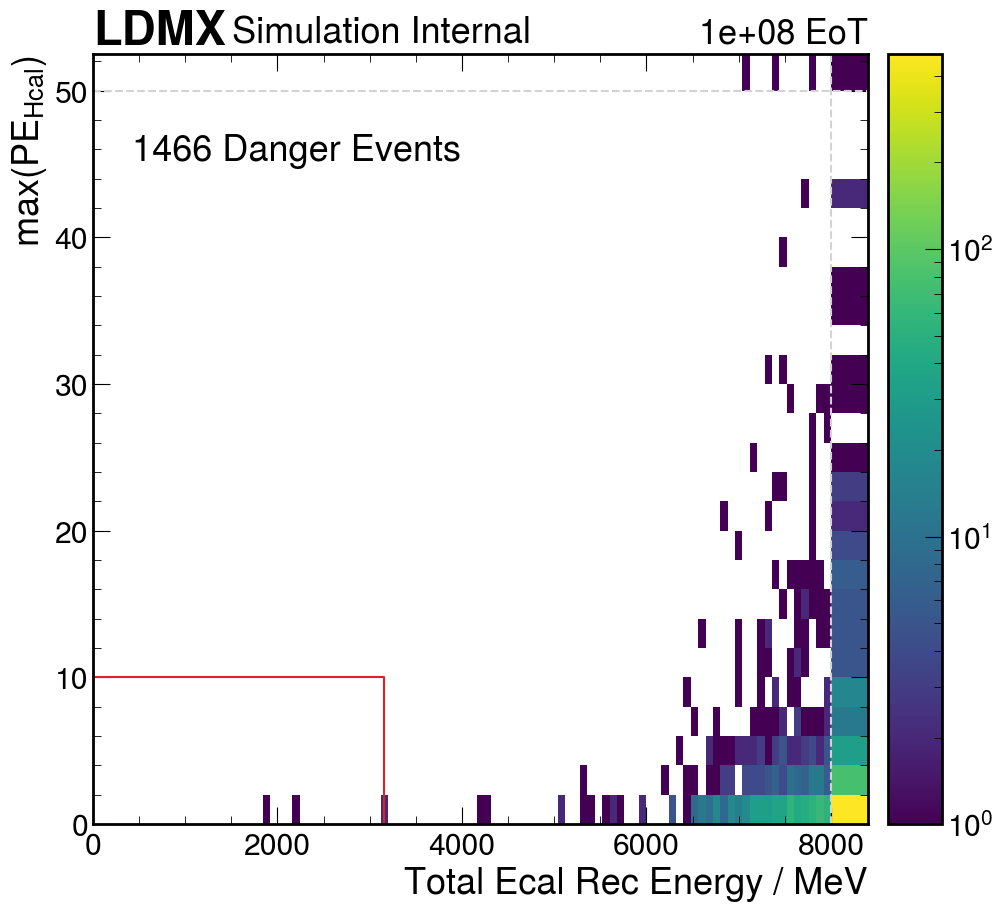

In [11]:
ana_plane.plot(
    norm='log',
    flow='show'
)
plt.plot(
    [3160, 3160, 0],
    [0, 10, 10],
    color='tab:red'
)
title_bar(f'{eot:.0e} EoT')
annotate(f'\n{len(ecal_hits)} Danger Events', loc='upper left')
plt.show()